## **0. Initialization**

### **Installation**
LoopDetectR is on CRAN and can be installed within R by

In [ ]:
# Before running the R code cells in jupyter notebook,
# initialize the R kernel by this line of code:
# IRkernel::installspec()

In [ ]:
# Download and install
install.packages("LoopDetectR")

Installing package into 'C:/Users/Admin/AppData/Local/R/win-library/4.5'
(as 'lib' is unspecified)



package 'LoopDetectR' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\Admin\AppData\Local\Temp\Rtmpk1kCL5\downloaded_packages


In [ ]:
install.packages("deSolve")  # if not already installed
install.packages("numDeriv") # if not already installed

Installing package into 'C:/Users/Admin/AppData/Local/R/win-library/4.5'
(as 'lib' is unspecified)



package 'deSolve' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\Admin\AppData\Local\Temp\Rtmpk1kCL5\downloaded_packages


Installing package into 'C:/Users/Admin/AppData/Local/R/win-library/4.5'
(as 'lib' is unspecified)



package 'numDeriv' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\Admin\AppData\Local\Temp\Rtmpk1kCL5\downloaded_packages


In [1]:
# Load package
library("LoopDetectR")
library(deSolve)
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.2.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
colors <- c('#EE7733', '#0077BB', '#33BBEE', '#EE3377', '#CC3311', '#009988', '#BBBBBB')

## **1. Model definition**

#### **Example 3: Model of complex formation with activation-deactivation cycle**

The model of complex formation with activation-deactivation cycle has also been investigated in [4]. It is composed of the basic model of complex formation in that A
and B bind to form complex AB as described in section 1.2, together with an activation and deactivation of one of the complex-forming species, B and B∗. In addition
to the two reactions of complex formation and complex decomposition, the activating
reaction and the deactivation reaction are modelled using Michaelis-Menten reaction
kinetics. Thereby, the activation of B to B∗
is in addition stimulus-dependent (the
stimulus is modelled as a parameter, kn3), while the deactivation of B∗
to B depends
linearly on species A. The model contains four species, A, B, AB, B∗
, four rate coefficients, k1 . . . , k4, two activation constants, kn1, kn2, and a stimulus parameter, kn3.

$$
\begin{aligned}
\frac{dA}{dt} &= -k_1\,A\,B + k_2\,AB ,\\[6pt]
\frac{dB}{dt} &= -k_1\,A\,B + k_2\,AB + k_3\,A\,\frac{B^*}{B^* + kn_1} - k_4\,kn_3\,\frac{B}{B + kn_2} ,\\[6pt]
\frac{d(AB)}{dt} &= k_1\,A\,B - k_2\,AB ,\\[6pt]
\frac{dB^*}{dt} &= -k_3\,A\,\frac{B^*}{B^* + kn_1} + k_4\,kn_3\,\frac{B}{B + kn_2} .
\end{aligned}
$$

We employed the following parameter set for the analyses: k1 = 0.021458, k2 =
0.000227335, k3 = 663.297, k4 = 0.000139797, kn1 = 55.5913, kn2 = 10.2194, and
values for the stimulus of kn3 = 1 (unstimulated) or kn3 = 20 (stimulated). The initial
conditions were set as A = 5, B = 300, AB = 0.0001, B∗ = 0.01.



In [3]:
func_varusai15 <- function(t, y, params) {
  A      <- y[1]
  B      <- y[2]
  AB     <- y[3]
  B_star <- y[4]

  k1  <- params[1]
  k2  <- params[2]
  k3  <- params[3]
  k4  <- params[4]
  kn1 <- params[5]
  kn2 <- params[6]
  kn3 <- params[7]

  dx <- rep(0,4)

  dAdt      <- -k1 * A * B + k2 * AB
  dBdt      <- -k1 * A * B + k2 * AB + k3 * A * (B_star / (B_star + kn1)) - k4 * kn3 * (B / (B + kn2))
  dABdt     <-  k1 * A * B - k2 * AB
  dB_stardt <- -k3 * A * (B_star / (B_star + kn1)) + k4 * kn3 * (B / (B + kn2))

  # list(c(dAdt, dBdt, dABdt, dB_stardt))
  dx[1] <- dAdt
  dx[2] <- dBdt
  dx[3] <- dABdt
  dx[4] <- dB_stardt
  return(dx)
}

## **2. Result reproduction**

In [4]:
# Parameters from supplementary material
initial_conditions_act_deact <- c(5, 300, 0.0001, 0.01)

k1 <- 0.021458
k2 <- 0.000227335
k3 <- 663.297
k4 <- 0.000139797
kn1 <- 55.5913
kn2 <- 10.2194
kn3_unstimulated <- 1.0
kn3_stimulated   <- 20.0

params_act_deact_unstimulated <- c(k1, k2, k3, k4, kn1, kn2, kn3_unstimulated)
params_act_deact_stimulated   <- c(k1, k2, k3, k4, kn1, kn2, kn3_stimulated)

### **2.1. Initialization**

#### **2.1.1. Loop structure**

In [113]:
# compute loops
res_tab <- find_loops_vset(func_varusai15,vset=list(initial_conditions_act_deact),t=1,params=params_act_deact_unstimulated,max_num_loops=10)
# The loop list is reported
res_tab$loop_rep[[1]] 
# To access a specific loop representation: e.g., the sixth loop, add [6,]

loop,length,sign
<I<list>>,<dbl>,<dbl>
"1, 1",1,-1
"2, 2",1,-1
"3, 3",1,-1
"4, 4",1,-1
"1, 2, 1",2,1
"1, 3, 1",2,1
"1, 3, 2, 1",3,-1
"2, 3, 1, 2",3,-1
"2, 3, 2",2,1


In [114]:
loop_summary(res_tab$loop_rep[[1]])

,len_1,len_2,len_3
,<dbl>,<dbl>,<dbl>
all,4,3,3
pos,0,3,1
neg,4,0,2


In [33]:
# Index of node of interest
noi <- 2 
# Return all loops from loop_list containing node 2
loop_list <- res_tab$loop_rep[[1]]
loop_list[vapply(loop_list$loop,function(x){noi %in% x},logical(1)),]

,loop,length,sign
,<I<list>>,<dbl>,<dbl>
2,"2, 2",1,-1
5,"1, 2, 1",2,1
7,"1, 3, 2, 1",3,-1
8,"2, 3, 1, 2",3,-1
9,"2, 3, 2",2,1
10,"1, 4, 2, 1",3,1


#### **2.1.2. Calculating the Jacobian matrix**

Sign jacobian matrix can be access via `res_tab` variable that we have calculated above, or derived from a jacobian matrix at a specific state

In [20]:
res_tab

loop,length,sign
<I<list>>,<dbl>,<dbl>
"1, 1",1,-1
"2, 2",1,-1
"3, 3",1,-1
"4, 4",1,-1
"1, 2, 1",2,1
"1, 3, 1",2,1
"1, 3, 2, 1",3,-1
"2, 3, 1, 2",3,-1
"2, 3, 2",2,1


In [21]:
# The corresponding signed Jacobian matrix
res_tab$jac_rep[[1]]

-1,-1,1,0
-1,-1,1,1
1,1,-1,0
-1,1,0,-1


The function jacobian from the numDeriv package can be used to determine numerically the Jacobian matrix of an ODE system at a certain set of values for the variables, `s_star`. The approach is that of finite differences (with real step) or complex step approach, the latter of which is supposed to deliver more exact results [Martins et al., 2003].

In [52]:
# The function func_POSm4 returns a vector, but deSolve needs the vector within
# a list as output. Therefore, we define a function that simply puts the output 
# of func_POSm4 into a list:
func_list <- function(t,x,params){list(func_varusai15(t,x,params))}
sol <-  deSolve::ode(y = initial_conditions_act_deact, times = seq(0,5000,0.1), func = func_list, 
                     parms=params_act_deact_unstimulated)

# Set the last point of the numeric solution as point of interest, omit the 
# first column (it contains the time)
s_star_end <- sol[dim(sol)[1],2:dim(sol)[2]]
s_star_end

1            2            3            4 
1.795958e-04 2.949471e+02 4.999920e+00 6.312347e-02

In [25]:
j_matrix <- numDeriv::jacobian(func_varusai15, initial_conditions_act_deact,method="complex",
                               t=1,params=params_act_deact_stimulated)
j_matrix

-6.4374000,-1.072900e-01,0.000227335,0.00000
-6.3181048,-1.072903e-01,0.000227335,59.63689
6.4374000,1.072900e-01,-0.000227335,0.00000
-0.1192952,2.969035e-07,0.000000000,-59.63689


In [26]:
signed_jacobian <- sign(j_matrix)
signed_jacobian

-1,-1,1,0
-1,-1,1,1
1,1,-1,0
-1,1,0,-1


#### **2.1.3. Temporal dynamics**

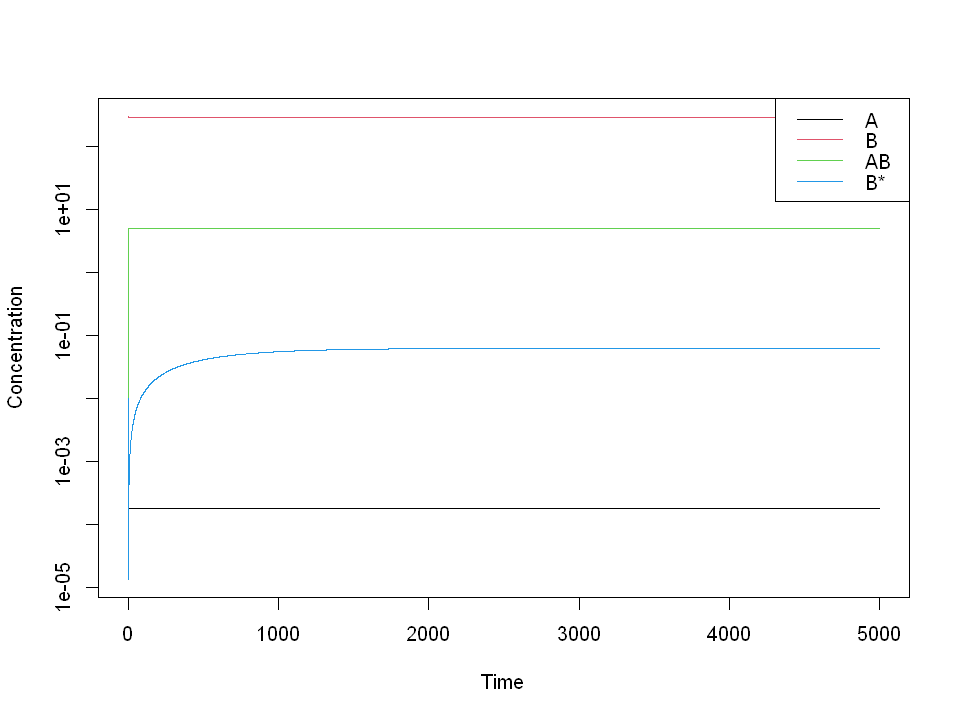

In [27]:
matplot(
  sol[,1], sol[,2:5],
  type = "l",
  lty = 1,
  log = "y",
  xlab = "Time",
  ylab = "Concentration",

)

legend(
  "topright",
  legend = c("A", "B", "AB", "B*"),
  col = 1:4,
  lty = 1
)

In [46]:
sol_for_plot <- as.data.frame(sol)

# rename columns for clarity
colnames(sol_for_plot) <- c("time", "A", "B", "AB", "B*")

# reshape to long format
sol_long <- sol_for_plot %>%
  pivot_longer(cols = A:`B*`, names_to = "species", values_to = "value")

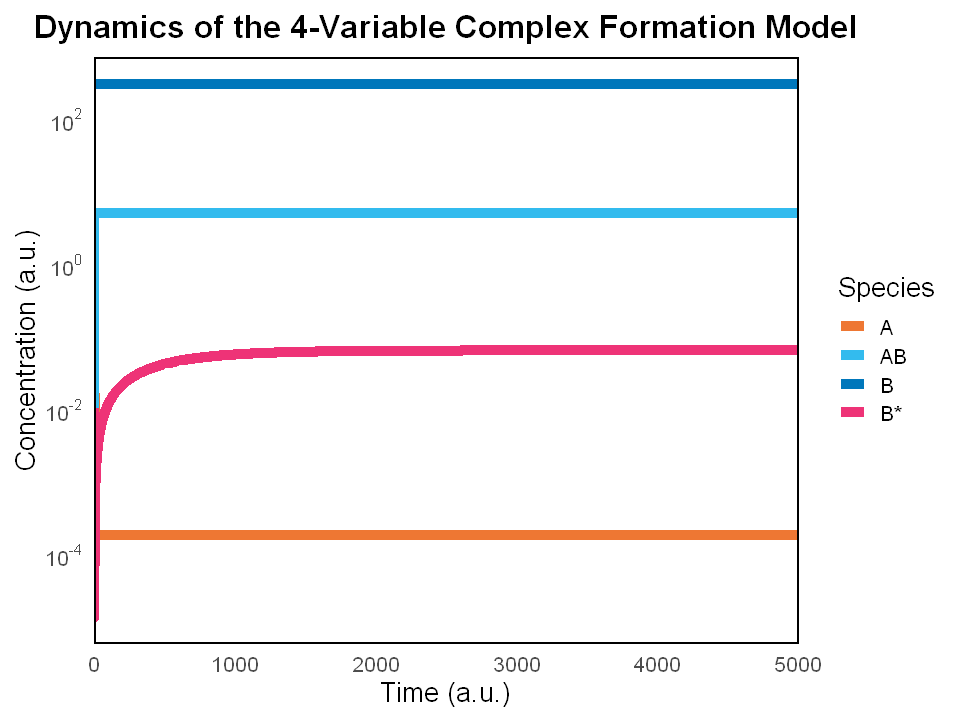

In [47]:
options(repr.plot.width = 8, repr.plot.height = 6)
colors <- c(
  A = "#EE7733",
  B = "#0077BB",
  AB = "#33BBEE",
  `B*` = "#EE3377"
)

plot1 <- ggplot(sol_long, aes(x = time, y = value, colour = species)) +
  geom_line(linewidth = 3) +
  ## vertical dashed line
  # geom_vline(
  #   xintercept = perturbation_point,
  #   linetype = "dashed",
  #   colour = "black",
  #   linewidth = 0.7
  # ) +
  scale_colour_manual(values = colors) + # scale_colour_brewer(palette = "Dark2") +
  scale_x_continuous(
    breaks = seq(0, 5000, 1000),
    minor_breaks = seq(0, 5000, 500),
    limits = c(0, 5000),
    expand = c(0, 0)
  ) +
  coord_cartesian(xlim = c(0, 5000), clip = "on") +
  scale_y_log10(
    breaks = scales::trans_breaks("log10", function(x) 10^x),
    labels = scales::trans_format("log10", scales::math_format(10^.x))
  ) +              # log10 transformation
  labs(
    title = "Dynamics of the 4-Variable Complex Formation Model",
    x = "Time (a.u.)",
    y = "Concentration (a.u.)",
    colour = "Species"
  ) +
  theme_minimal(base_size = 16) +
  theme(
    plot.title = element_text(face = "bold", hjust = 0.5),
    # panel.grid.minor = element_blank(),
    panel.grid = element_blank(),

    ## black outer box
    panel.border = element_rect(
      colour = "black",
      fill = NA,
      linewidth = 1.1
    )
  )

plot1
# ggsave("POSm4_plot.png", plot1, width = 10, height = 8, units = "in", dpi = 300)

### **2.2. Stimulated Condition**

When introducing a stimulus at t=0 which increases kn3 from 1 to 20

In [61]:
# Now, draw temporal dynamics for unstimulated conditions from t=[-1000, 0], and then stimulated conditions from t=[0, 2000]
time_1 <- seq(-1000, 0, 0.1)
time_2 <- seq(0, 2000, 0.1)
sol_unstimulated <-  deSolve::ode(y = as.numeric(s_star_end), times = time_1, func = func_list, 
                              parms=params_act_deact_unstimulated)
sol_stimulated <-  deSolve::ode(y = sol_unstimulated[nrow(sol_unstimulated),2:5], times = time_2, func = function(t,x,params){list(func_varusai15(t,x,params_act_deact_stimulated))}, 
                            parms=params_act_deact_stimulated)

time_full <- c(time_1, time_2)
sol_full <- rbind(sol_unstimulated, sol_stimulated) 

In [72]:
sol_unstimulated[nrow(sol_unstimulated),2:5]

1            2            3            4 
1.795958e-04 2.949471e+02 4.999920e+00 6.312473e-02

In [73]:
nrow(sol_unstimulated)

[1] 10001

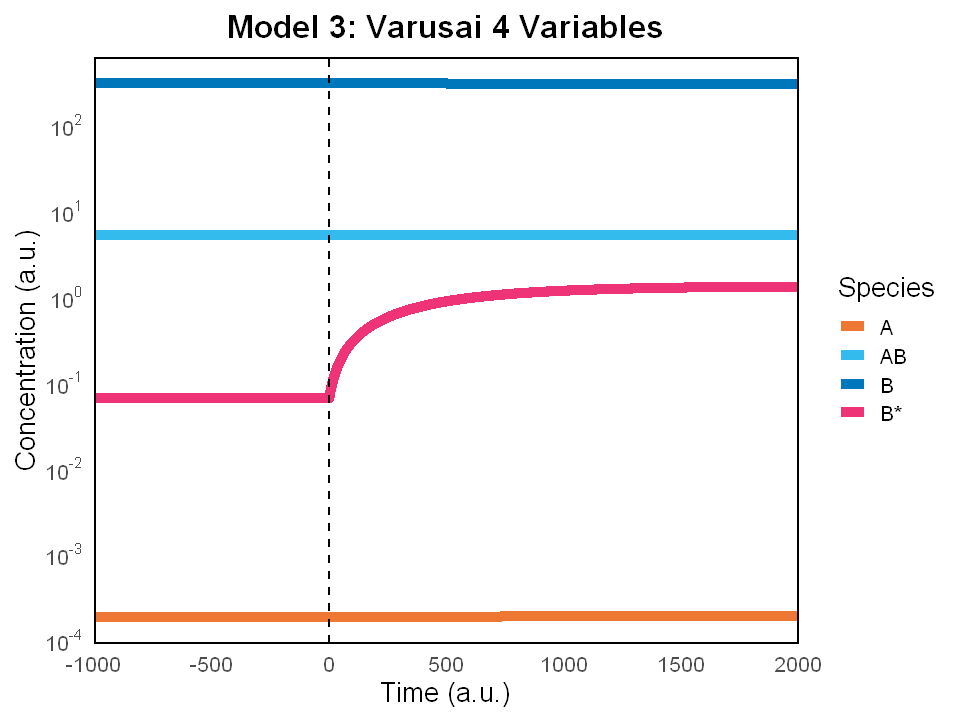

In [123]:
# Plotting
sol_for_plot_2 <- as.data.frame(sol_full)
# rename columns for clarity
colnames(sol_for_plot_2) <- c("time", "A", "B", "AB", "B*")
# reshape to long format
sol_long <- sol_for_plot_2 %>%
  pivot_longer(cols = A:`B*`, names_to = "species", values_to = "value")
options(repr.plot.width = 8, repr.plot.height = 6)
colors <- c(
  A = "#EE7733",
  B = "#0077BB",
  AB = "#33BBEE",
  `B*` = "#EE3377"
)
plot1 <- ggplot(sol_long, aes(x = time, y = value, colour = species)) +
    geom_line(linewidth = 3) +
    ## vertical dashed line
    geom_vline(
        xintercept = 0,
        linetype = "dashed",
        colour = "black",
        linewidth = 0.7
    ) +
    scale_colour_manual(values = colors) + # scale_colour_brewer(palette = "Dark2") +
    scale_x_continuous(
        breaks = seq(-1000, 2000, 500),
        minor_breaks = seq(-1000, 2000, 250),
        limits = c(-1000, 2000),
        expand = c(0, 0)
    ) +
    coord_cartesian(xlim = c(-1000, 2000), clip = "on"
    ) +
    scale_y_log10(
        breaks = scales::trans_breaks("log10", function(x) 10^x),
        labels = scales::trans_format("log10", scales::math_format(10^.x))
        ) +              # log10 transformation
    labs(
        title = "Model 3: Varusai 4 Variables",
        x = "Time (a.u.)",
        y = "Concentration (a.u.)",
        colour = "Species"
        ) +
    theme_minimal(base_size = 16) +
    theme(
        plot.title = element_text(face = "bold", hjust = 0.5),
        # panel.grid.minor = element_blank(),
        panel.grid = element_blank(),
        
        ## black outer box
        panel.border = element_rect(
            colour = "black",
            fill = NA,
            linewidth = 1.1
            )
        )

plot1

In [107]:
# Search for changes in loops upon stimulation over time_full
res_tab_0 <- find_loops_vset(func_varusai15,vset=list(initial_conditions_act_deact),t=1,params=params_act_deact_unstimulated,max_num_loops=10)
j_0 <- res_tab_0$jac_rep[[1]]

for (idx in 1:(nrow(sol_full))) {
  # compute loopsl
  res_tab <- find_loops_vset(func_varusai15,vset=list(sol_full[idx,2:5]),t=idx,params=params_act_deact_stimulated,max_num_loops=10)
  j_1 <- res_tab$jac_rep[[1]]
  if (!identical(j_0, j_1)) {
    print(paste("Jacobian matrix changed at index", idx, "and time", time_full[idx], sep=" "))
    print("Unstimulated Jacobian:")
    print(j_0)
    print("Stimulated Jacobian:")
    print(j_1)
    break
  }
}

[1] "Jacobian matrix changed at index 12332 and time 233"
[1] "Unstimulated Jacobian:"
     [,1] [,2] [,3] [,4]
[1,]   -1   -1    1    0
[2,]   -1   -1    1    1
[3,]    1    1   -1    0
[4,]   -1    1    0   -1
[1] "Stimulated Jacobian:"
     [,1] [,2] [,3] [,4]
[1,]   -1   -1    1    0
[2,]    1   -1    1    1
[3,]    1    1   -1    0
[4,]   -1    1    0   -1


In [115]:
res_tab_0 <- find_loops_vset(func_varusai15,vset=list(initial_conditions_act_deact),t=1,params=params_act_deact_unstimulated)
print("Loop summary unstimulated conditions:")
loop_summary(res_tab_0$loop_rep[[1]])

[1] "Loop summary unstimulated conditions:"


,len_1,len_2,len_3,len_4
,<dbl>,<dbl>,<dbl>,<dbl>
all,4,4,3,1
pos,0,4,1,0
neg,4,0,2,1


In [116]:
res_tab <- find_loops_vset(func_varusai15,vset=list(sol_full[idx,2:5]),t=idx,params=params_act_deact_stimulated)
print("Loop summary stimulated conditions:")
loop_summary(res_tab$loop_rep[[1]])

[1] "Loop summary stimulated conditions:"


,len_1,len_2,len_3,len_4
,<dbl>,<dbl>,<dbl>,<dbl>
all,4,4,3,1
pos,0,3,2,0
neg,4,1,1,1


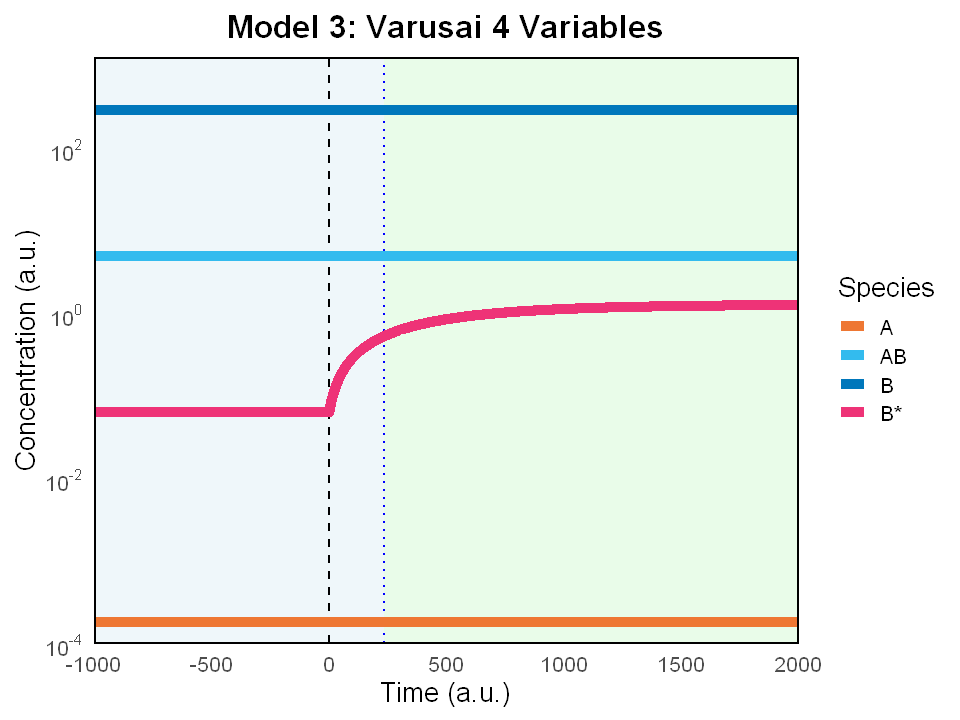

In [139]:
# Plot again including the color area in the background to indicate unstimulated and stimulated loop structures changes (at idx, t)
options(repr.plot.width = 8, repr.plot.height = 6)
colors <- c(
  A = "#EE7733",
  B = "#0077BB",
  AB = "#33BBEE",
  `B*` = "#EE3377"
)

t_change <- time_full[idx]
yr <- range(sol_long$value, na.rm = TRUE)

plot2 <- ggplot(sol_long, aes(x = time, y = value, colour = species)) +
    # Add background colored areas 
    annotate("rect",
           xmin = -1000, xmax = t_change,
           ymin = 10**-4, ymax = yr[2]+1000,
           alpha = 0.2, fill = "lightblue") +
    annotate("rect",
           xmin = t_change, xmax = 2000,
           ymin = 10**-4, ymax = yr[2]+1000,
           alpha = 0.2, fill = "lightgreen") +
    ## vertical dashed line
    geom_vline(
        xintercept = 0,
        linetype = "dashed",
        colour = "black",
        linewidth = 0.7
    ) +
    ## Another vertical line at the time of loop structure change
    geom_vline(
        xintercept = t_change,
        linetype = "dotted",
        colour = "blue",
        linewidth = 0.7
    ) +
    ## Trajectory lines
    geom_line(linewidth = 3) +
    scale_colour_manual(values = colors) + # scale_colour_brewer(palette = "Dark2") +
    scale_x_continuous(
        breaks = seq(-1000, 2000, 500),
        minor_breaks = seq(-1000, 2000, 250),
        limits = c(-1000, 2000),
        expand = c(0, 0)
    ) +
    coord_cartesian(xlim = c(-1000, 2000), clip = "on", ylim = c(10**-4, yr[2]+1000)
    ) +
    scale_y_log10(
        breaks = scales::trans_breaks("log10", function(x) 10^x),
        labels = scales::trans_format("log10", scales::math_format(10^.x)),
        limits = c(10**-4, yr[2]+1000),
        expand = c(0, 0)
        ) +              # log10 transformation
    labs(
        title = "Model 3: Varusai 4 Variables",
        x = "Time (a.u.)",
        y = "Concentration (a.u.)",
        colour = "Species"
        ) +
    theme_minimal(base_size = 16) +
    theme(
        plot.title = element_text(face = "bold", hjust = 0.5),
        # panel.grid.minor = element_blank(),
        panel.grid = element_blank(),
        
        ## black outer box
        panel.border = element_rect(
            colour = "black",
            fill = NA,
            linewidth = 1.1
            )
        )
plot2
# ggsave("POSm4_plot_stimulated_loops.png", plot2, width = 10, height = 8, units = "in", dpi = 300)

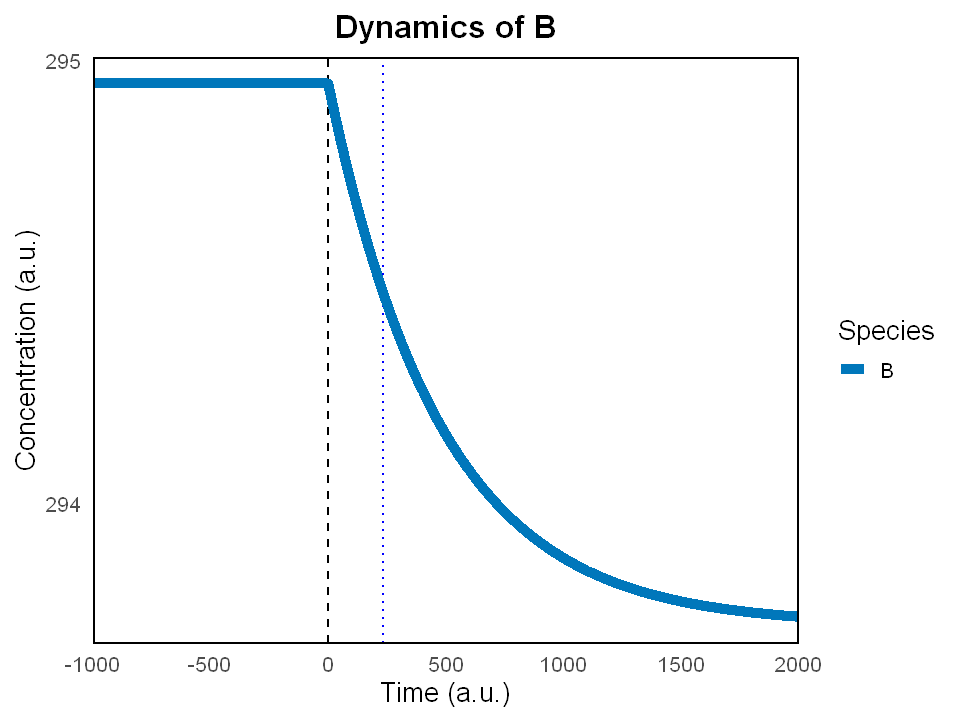

In [149]:
# Zoom in around the perturbation point to see the dynamics more clearly (of only B)
options(repr.plot.width = 8, repr.plot.height = 6)

plot3 <- ggplot(sol_long %>% filter(species == "B"), aes(x = time, y = value, colour = species)) +
    ## vertical dashed line
    geom_vline(
        xintercept = 0,
        linetype = "dashed",
        colour = "black",
        linewidth = 0.7
    ) +
    ## Another vertical line at the time of loop structure change
    geom_vline(
        xintercept = t_change,
        linetype = "dotted",
        colour = "blue",
        linewidth = 0.7
    ) +
    ## Trajectory lines
    geom_line(linewidth = 3) +
    scale_colour_manual(values = colors) + # scale_colour_brewer(palette = "Dark2") +
    scale_x_continuous(
        breaks = seq(-1000, 2000, 500),
        minor_breaks = seq(-1000, 2000, 250),
        limits = c(-1000, 2000),
        expand = c(0, 0)
    ) +
    coord_cartesian(xlim = c(-1000, 2000), clip = "on"
    ) +
    scale_y_continuous(
        minor_breaks = seq(-293, 295, 0.2),
        breaks = seq(-293, 295, 1),
    #     limits = c(10**-2, yr[2]+1000),
    #     expand = c(0, 0)
        ) +     
    labs(
        title = "Dynamics of B",
        x = "Time (a.u.)",
        y = "Concentration (a.u.)",
        colour = "Species"
        ) +
    theme_minimal(base_size = 16) +
    theme(
        plot.title = element_text(face = "bold", hjust = 0.5),
        # panel.grid.minor = element_blank(),
        panel.grid = element_blank(),
        
        ## black outer box
        panel.border = element_rect(
            colour = "black",
            fill = NA,
            linewidth = 1.1
            )
        )
plot3
# ggsave("POSm4_plot_stimulated_loops_zoomed.png", plot